In [1]:
import sys
sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras

import bayesflow as bf

from dmc import DMC, dmc_helpers

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D


network_names = [
    'updated_priors_sdr_fixed',
    'updated_priors_sdr_estimated',
    'initial_priors_sdr_fixed',
    'initial_priors_sdr_estimated',
]

num_resims = 100
host = 'local'

parent_dir = os.path.dirname(os.getcwd())

lst_model_specs = {}

simulators = {}

approximators = {}

for network_name in network_names:

    model_specs_path = parent_dir + '/model_specs/model_specs_' + network_name + '.pickle'
    with open(model_specs_path, 'rb') as file:
        model_specs = pickle.load(file)
    
    lst_model_specs[network_name] = model_specs

    simulators[network_name] = DMC(**model_specs['simulation_settings'])

    approximators[network_name] = keras.saving.load_model(parent_dir + "/training_checkpoints/" + network_name + '.keras')



INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
/home/administrator/miniforge3/envs/bf_new/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 159 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Load PPC data

Before running this script, please make sure to compute empirical estimates (scripts/empirical_estimates.py) and posterior predictive resimulations (scripts/posterior_predictive_check_data.py)

In [2]:
ppc_data_raw = pd.read_csv(parent_dir+'/data_complete/ppc_data/ppc_data_raw.csv')

In [3]:
### resim quantiles
group_cols = ["participant", "condition_label", "spacing", "model"]

# 1) Quantiles of RT (long format)
df_q = (
    ppc_data_raw
        .groupby(group_cols)["rt"]
        .quantile([0.25, 0.5, 0.75])
        .rename_axis(index=[*group_cols, "quantile"])
        .reset_index()
)

# 2) Mean RT and mean accuracy per group
df_means = (
    ppc_data_raw
        .groupby(group_cols)
        .agg(
            mean_rt=("rt", "mean"),
            mean_acc=("accuracy", "mean"),  
        )
        .reset_index()
)

# 3) Combine quantiles with means
df_q = df_q.merge(df_means, on=group_cols)

# Pivot quantiles to wide format
df_q_wide = (
    df_q
        .pivot_table(
            index=group_cols + ["mean_rt", "mean_acc"],
            columns="quantile",
            values="rt"
        )
        .reset_index()
)

# Rename quantile columns to clear variable names
df_q_wide = df_q_wide.rename(
    columns={
        0.25: "rt_q25",
        0.50: "rt_q50",
        0.75: "rt_q75",
    }
)

## Load Empirical Data

In [4]:

narrow_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_narrow.csv')

wide_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_wide.csv')

empirical_data = pd.concat([narrow_data, wide_data])


In [5]:
empirical_data['condition_label'] = empirical_data['congruency_num'].map({0: 'congruent', 1:'incongruent'})

empirical_data['spacing'] = empirical_data['spacing_num'].map({0: 'wide', 1:'narrow'})

In [6]:
empirical_data

,Unnamed: 0,participant,rt,accuracy,congruency_num,spacing_num,condition_label,spacing
0,0,6361,0.4690,1,0,1,congruent,narrow
1,1,5281,0.4540,1,0,1,congruent,narrow
2,2,8785,0.4345,1,0,1,congruent,narrow
3,3,6253,0.2900,1,1,1,incongruent,narrow
4,4,6427,0.5150,1,0,1,congruent,narrow
...,...,...,...,...,...,...,...,...
24884,25532,985,0.3440,1,0,0,congruent,wide
24885,25533,985,0.4960,0,1,0,incongruent,wide
24886,25534,985,0.4830,1,0,0,congruent,wide
24887,25535,985,0.5410,1,1,0,incongruent,wide


In [7]:
empirical_data = empirical_data[['participant', 'rt','accuracy', 'condition_label', 'spacing']]

In [8]:
empirical_data

,participant,rt,accuracy,condition_label,spacing
0,6361,0.4690,1,congruent,narrow
1,5281,0.4540,1,congruent,narrow
2,8785,0.4345,1,congruent,narrow
3,6253,0.2900,1,incongruent,narrow
4,6427,0.5150,1,congruent,narrow
...,...,...,...,...,...
24884,985,0.3440,1,congruent,wide
24885,985,0.4960,0,incongruent,wide
24886,985,0.4830,1,congruent,wide
24887,985,0.5410,1,incongruent,wide


In [9]:
group_cols = ["participant", "condition_label", "spacing"]

# 1) Quantiles of RT (long format)
df_q_emp = (
    empirical_data
        .groupby(group_cols)["rt"]
        .quantile([0.25, 0.5, 0.75])
        .rename_axis(index=[*group_cols, "quantile"])
        .reset_index()
)

# 2) Mean RT and mean accuracy per group
df_means_emp = (
    empirical_data
        .groupby(group_cols)
        .agg(
            mean_rt=("rt", "mean"),
            mean_acc=("accuracy", "mean"), 
        )
        .reset_index()
)

# 3) Combine quantiles with means
df_q_emp = df_q_emp.merge(df_means_emp, on=group_cols)

# Pivot quantiles to wide format
df_q_emp_wide = (
    df_q_emp
        .pivot_table(
            index=group_cols + ["mean_rt", "mean_acc"],
            columns="quantile",
            values="rt"
        )
        .reset_index()
)

# Rename quantile columns to clear variable names
df_q_emp_wide = df_q_emp_wide.rename(
    columns={
        0.25: "rt_q25",
        0.50: "rt_q50",
        0.75: "rt_q75",
    }
)



In [10]:
df_q_emp_wide

quantile,participant,condition_label,spacing,mean_rt,mean_acc,rt_q25,rt_q50,rt_q75
0,275,congruent,narrow,0.436022,0.983607,0.380000,0.41500,0.472000
1,275,congruent,wide,0.442846,0.988571,0.393500,0.42900,0.467500
2,275,incongruent,narrow,0.477984,0.989362,0.413000,0.46700,0.529250
3,275,incongruent,wide,0.441041,0.988372,0.380000,0.41700,0.483000
4,808,congruent,narrow,0.469180,0.977273,0.404375,0.45445,0.505575
...,...,...,...,...,...,...,...,...
283,161753,incongruent,wide,0.437897,1.000000,0.400500,0.43100,0.464500
284,337788,congruent,narrow,0.452593,1.000000,0.403500,0.43800,0.486000
285,337788,congruent,wide,0.449862,0.994253,0.404250,0.43650,0.486000
286,337788,incongruent,narrow,0.478908,0.988506,0.422000,0.47000,0.519000


In [11]:
df_q_wide

quantile,participant,condition_label,spacing,model,mean_rt,mean_acc,rt_q25,rt_q50,rt_q75
0,275,congruent,narrow,initial_priors_sdr_estimated,0.439498,0.994409,0.380211,0.423877,0.481816
1,275,congruent,narrow,initial_priors_sdr_fixed,0.441511,0.997204,0.375710,0.424028,0.487060
2,275,congruent,narrow,updated_priors_sdr_estimated,0.440186,0.988710,0.382247,0.422868,0.479107
3,275,congruent,narrow,updated_priors_sdr_fixed,0.434988,0.995376,0.371661,0.416048,0.476670
4,275,congruent,wide,initial_priors_sdr_estimated,0.439325,0.983563,0.384608,0.427616,0.481520
...,...,...,...,...,...,...,...,...,...
1147,337788,incongruent,narrow,updated_priors_sdr_fixed,0.478065,0.993333,0.418317,0.468660,0.524941
1148,337788,incongruent,wide,initial_priors_sdr_estimated,0.461229,0.980800,0.406475,0.452500,0.504730
1149,337788,incongruent,wide,initial_priors_sdr_fixed,0.464059,0.995886,0.400632,0.451874,0.512892
1150,337788,incongruent,wide,updated_priors_sdr_estimated,0.461728,0.973829,0.406179,0.451481,0.504932


In [12]:
data_merged = pd.merge(df_q_wide, df_q_emp_wide, how='left', on=['participant', 'spacing', 'condition_label'], suffixes=['_resim', '_emp'])

In [13]:
con_color = '#10225e'
inc_color = '#FF6361'

# Define custom legend elements
legend_elements = [
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='Observed'),
    Line2D([0], [0], color='black', lw=2, linestyle=':', label='Resimulated'),
    Line2D([0], [0], color=con_color, lw=2, label='Congruent'),
    Line2D([0], [0], color=inc_color, lw=2, label='Incongruent'),
]

hue_order = ["congruent", "incongruent"]
palette = {"congruent": con_color, "incongruent": inc_color}

names = ['Mean RT', 'Mean Accuracy', '25% Quantile RT', 'Median RT','75% Quantile RT']


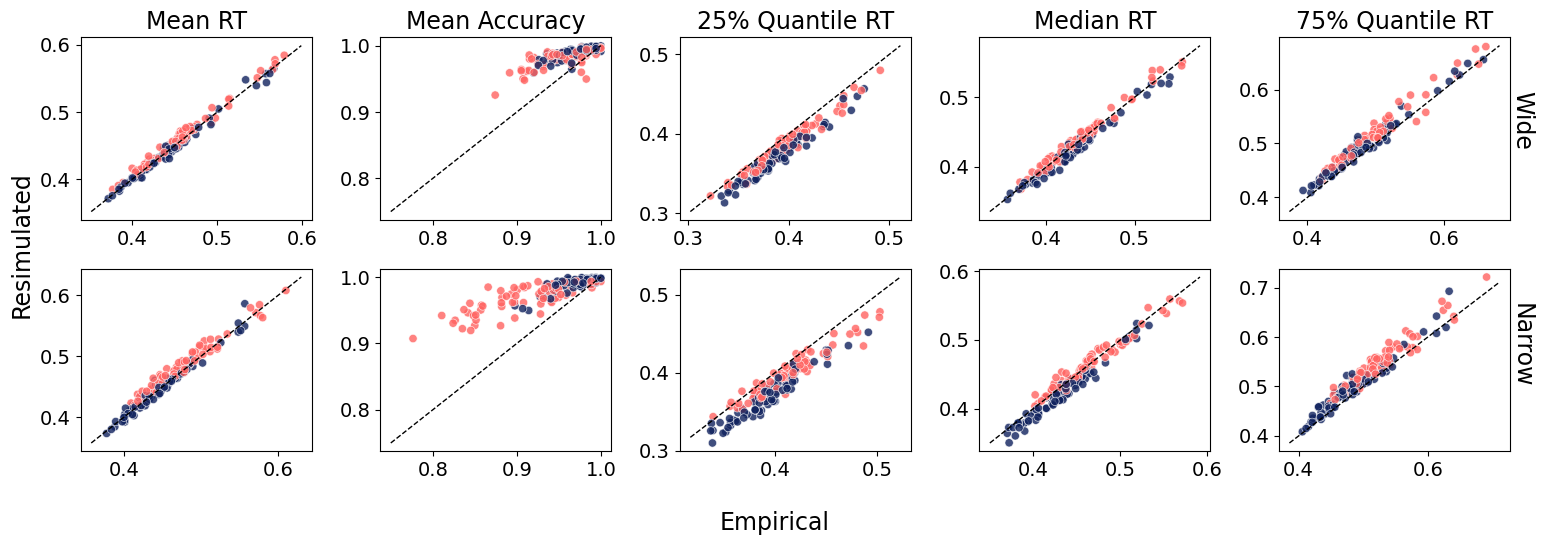

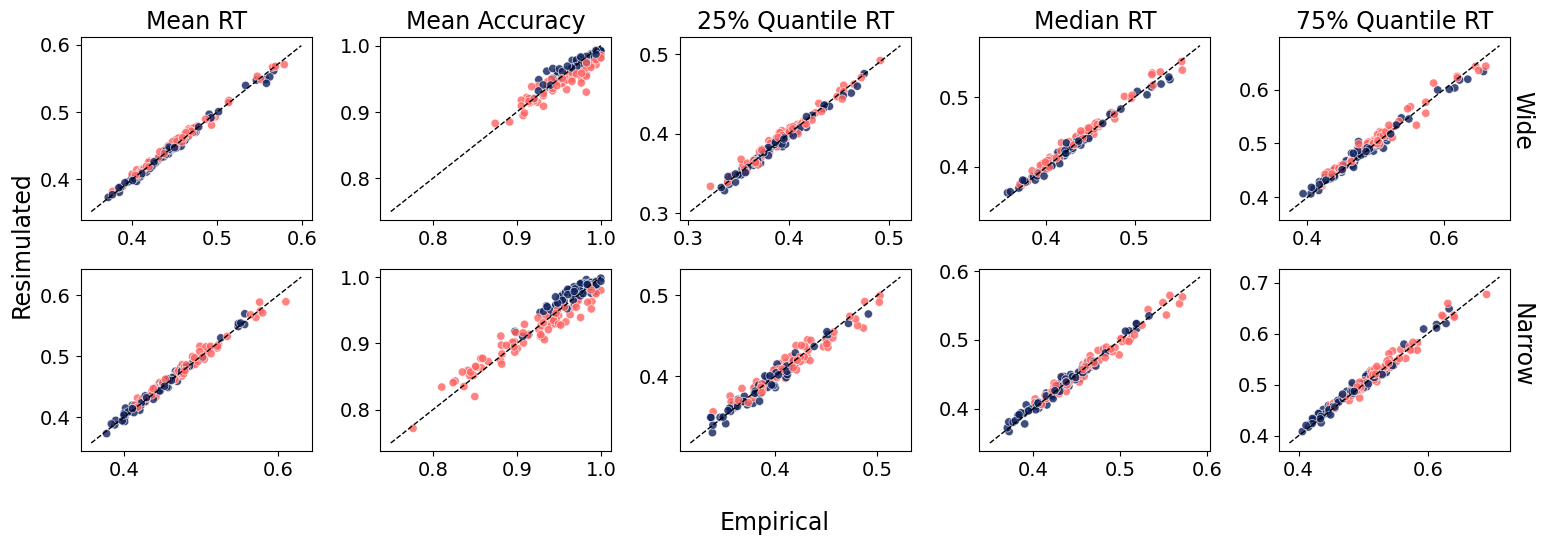

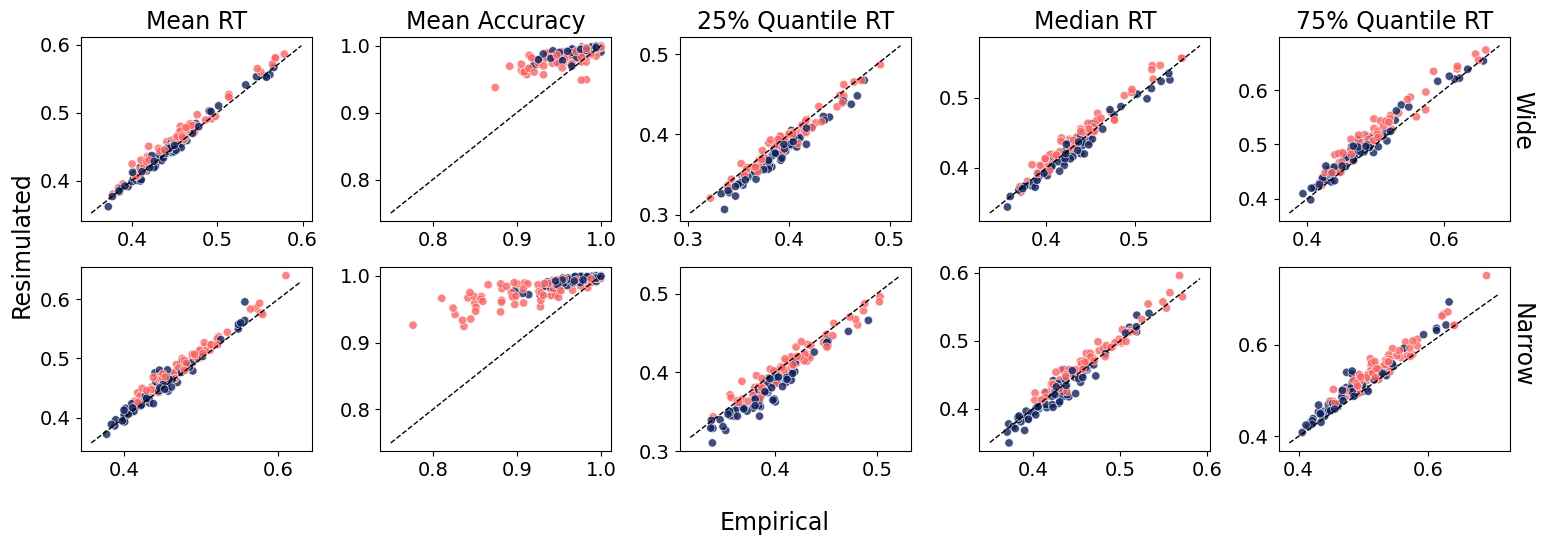

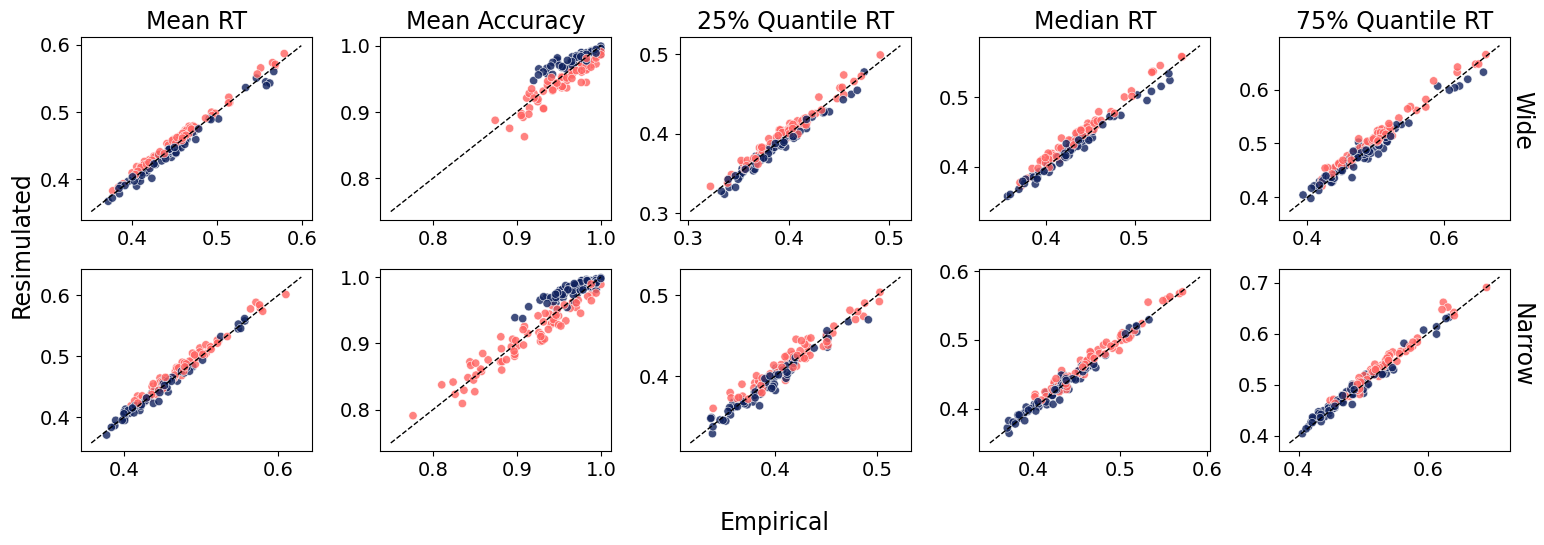

In [14]:

for network_name in network_names:

    plot_data = data_merged[data_merged['model'] == network_name]

    fig, axes = plt.subplots(2, 5, figsize= (15,5))

    fontsize = 22

    for spacing_label, spacing in zip(('narrow', 'wide'), (1,0)):

        spacing_data = plot_data[plot_data['spacing'] == spacing_label]

        for j, var in enumerate(['mean_rt', 'mean_acc', 'rt_q25', 'rt_q50', 'rt_q75']):

            sns.scatterplot(data=spacing_data, x= var+'_emp', y= var+'_resim', hue='condition_label', ax=axes[spacing, j], hue_order=hue_order, palette=palette, alpha=0.8, legend = False)

            if var != 'mean_acc':
                lims = [spacing_data[var+'_emp'].min() - 0.02, spacing_data[var+'_emp'].max() + 0.02]
            else:
                lims = [.75, 1]

            axes[spacing,j].plot(lims, lims, color='black', linestyle='--', linewidth=1)

            if j == 0:
                axes[spacing,j].set_ylabel('Resimulated')
            else:
                axes[spacing,j].set_ylabel('')

            if spacing == 1:
                axes[spacing,j].set_xlabel('Empirical')
            else:
                axes[spacing,j].set_xlabel('')
            
            if spacing == 0:
                axes[spacing,j].set_title(names[j], fontsize = fontsize - 5)

            axes[spacing,j].tick_params(axis='x', labelsize=fontsize - 8)  
            axes[spacing,j].tick_params(axis='y', labelsize=fontsize - 8)
            axes[spacing,j].set_xlabel("")
            axes[spacing,j].set_ylabel("")


    fig.text(.99, 0.75, 'Wide', va='center', ha='left', fontsize=fontsize - 5, rotation=270)
    fig.text(.99, 0.3, 'Narrow', va='center', ha='left', fontsize=fontsize - 5, rotation=270)

    fig.tight_layout()

    fig.supxlabel("Empirical", fontsize=fontsize-5, y = -0.08) 
    fig.supylabel("Resimulated", fontsize=fontsize-5, x = -.01) 


    #fig.savefig(parent_dir + '/plots/ppc/' + network_name + '_mean_rt_mean_acc.png', bbox_inches='tight')